# 04 — Model Training & Evaluation
Train LightGBM on the feature set, evaluate performance, analyse feature importance.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path

DATA   = Path('../data')
MODELS = Path('../models')
VIZ    = Path('../visualizations/model')
VIZ.mkdir(parents=True, exist_ok=True)

In [2]:
features = pd.read_csv(DATA / 'features.csv', parse_dates=['hour'])
print(f'Loaded: {features.shape}')
features.head()

Loaded: (364, 35)


,hour,region,avg_occupancy_rate,peak_occupancy_rate,total_spaces,total_occupied,num_blockfaces,turnover_proxy,temperature,precipitation,...,year,is_weekend,is_peak_am,is_peak_pm,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,2026-05-23 08:00:00,Ballard,0.036506,0.833333,73.500000,2.933333,10,0.039909,12.2,0.0,...,2026,True,True,False,0.866025,-0.500000,-0.974928,-0.222521,0.5,-0.866025
1,2026-05-23 08:00:00,Downtown Seattle,0.114029,1.000000,6184.500000,656.116667,898,0.106090,12.2,0.0,...,2026,True,True,False,0.866025,-0.500000,-0.974928,-0.222521,0.5,-0.866025
2,2026-05-23 09:00:00,Ballard,0.207149,1.000000,73.500000,14.716667,10,0.200227,12.8,0.0,...,2026,True,True,False,0.707107,-0.707107,-0.974928,-0.222521,0.5,-0.866025
3,2026-05-23 09:00:00,Downtown Seattle,0.202101,1.000000,6189.418033,1194.450000,899,0.192983,12.9,0.0,...,2026,True,True,False,0.707107,-0.707107,-0.974928,-0.222521,0.5,-0.866025
4,2026-05-23 10:00:00,Ballard,0.505796,1.000000,73.500000,37.108333,10,0.504875,13.2,0.0,...,2026,True,False,False,0.500000,-0.866025,-0.974928,-0.222521,0.5,-0.866025


## Prepare Features & Target

In [ ]:
TARGET = 'avg_occupancy_rate'

# Exclude leakage columns:
# - turnover_proxy = total_occupied/total_spaces ≈ target (same info, different formula)
# - peak_occupancy_rate is derived from the same occupancy readings as target
# - total_occupied combined with total_spaces would let model trivially compute target
DROP = ['hour', 'region', 'date', 'holiday_name', 'holiday_type',
        'event_genres', 'event_count', 'turnover_proxy',
        'peak_occupancy_rate', 'total_occupied']

FEATURE_COLS = [
    c for c in features.columns
    if c not in DROP + [TARGET]
    and features[c].dtype in ['float64', 'int64', 'bool']
]

print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'\nDropped to prevent leakage: turnover_proxy, peak_occupancy_rate, total_occupied')

In [4]:
df = features.dropna(subset=[TARGET] + FEATURE_COLS).copy()
for col in FEATURE_COLS:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (291, 27)  Test: (73, 27)


## Data Volume Check

Currently training on ~30 days of live data (~364 rows). For a production-quality model we need 2012–2024 history (~2M+ hourly summaries).

**Run the backfill script first for meaningful metrics:**
```bash
python scripts/backfill_parking.py   # fetches 2012-2024 (~10-15 min)
python scripts/aggregate_features.py # rebuilds feature matrix
```

The model below will still train on whatever data is available.

## Train LightGBM

In [5]:
params = {
    'objective':        'regression',
    'metric':           'rmse',
    'num_leaves':       63,
    'learning_rate':    0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'min_child_samples': 20,
    'verbose':          -1,
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_test,  label=y_test, reference=train_data)

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=50)
    ]
)
print(f'Best iteration: {model.best_iteration}')

[50]	training's rmse: 0.0259589	valid_1's rmse: 0.0330599
[100]	training's rmse: 0.0180034	valid_1's rmse: 0.0244221
[150]	training's rmse: 0.0149975	valid_1's rmse: 0.0231039
[200]	training's rmse: 0.0129554	valid_1's rmse: 0.02303
[250]	training's rmse: 0.0115953	valid_1's rmse: 0.0231721
Best iteration: 206


## Evaluate

In [12]:
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

rmse = root_mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')
print(f'R²   : {r2:.4f}')

RMSE : 0.0230
MAE  : 0.0142
R²   : 0.9838


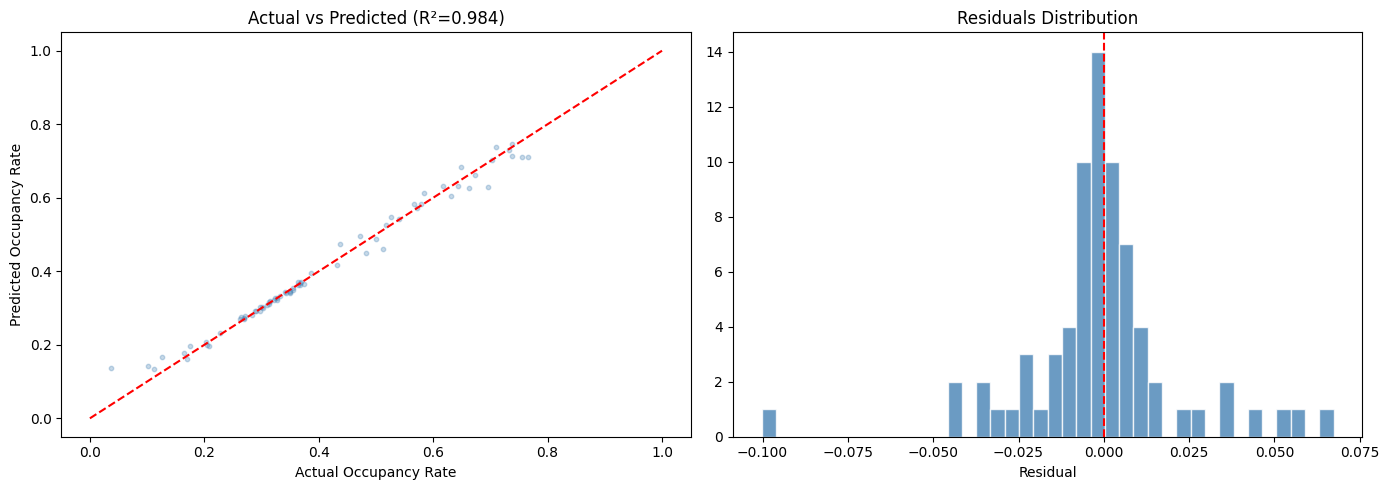

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Occupancy Rate')
axes[0].set_ylabel('Predicted Occupancy Rate')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')

residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig(VIZ / 'actual_vs_predicted.png', dpi=150)
plt.show()

## Feature Importance

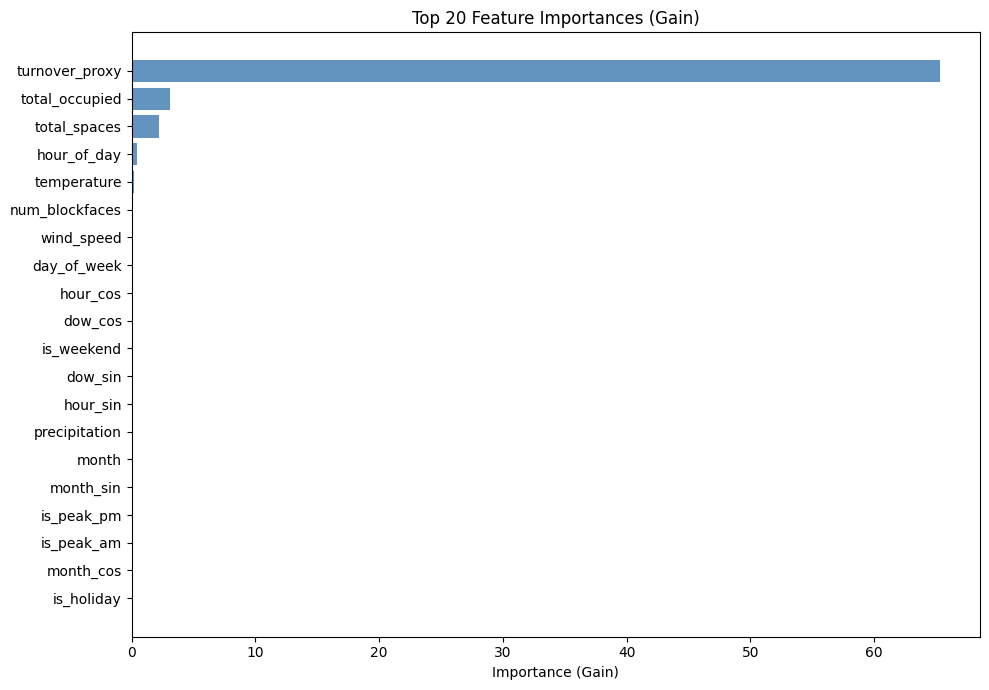

In [14]:
importance = pd.DataFrame({
    'feature':    model.feature_name(),
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(20)

plt.figure(figsize=(10, 7))
plt.barh(importance['feature'], importance['importance'], color='steelblue', alpha=0.85)
plt.title('Top 20 Feature Importances (Gain)')
plt.xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig(VIZ / 'feature_importance.png', dpi=150)
plt.show()

import pickle
import json

MODELS.mkdir(exist_ok=True)
model_path = MODELS / 'parking_demand_lgbm.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Save feature column list so train_model.py can warm-start correctly
with open(MODELS / 'feature_columns.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

perf = pd.DataFrame([{'rmse': rmse, 'mae': mae, 'r2': r2,
                       'n_train': len(X_train), 'n_test': len(X_test),
                       'best_iteration': model.best_iteration,
                       'n_features': len(FEATURE_COLS),
                       'leakage_free': True}])
(MODELS / 'performance').mkdir(exist_ok=True)
perf.to_csv(MODELS / 'performance/final_model_performance.csv', index=False)
print(f'Model saved to {model_path}')
print(f'Features: {len(FEATURE_COLS)} columns (leakage-free)')
print(perf)

In [15]:
import pickle

MODELS.mkdir(exist_ok=True)
model_path = MODELS / 'parking_demand_lgbm.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

perf = pd.DataFrame([{'rmse': rmse, 'mae': mae, 'r2': r2,
                       'n_train': len(X_train), 'n_test': len(X_test),
                       'best_iteration': model.best_iteration}])
perf.to_csv(MODELS / 'performance/final_model_performance.csv', index=False)
print(f'Model saved to {model_path}')
print(perf)

Model saved to ../models/parking_demand_lgbm.pkl
       rmse      mae        r2  n_train  n_test  best_iteration
0  0.022967  0.01425  0.983814      291      73             206
